# 5장 2강: 검정력 분석과 MDE 기반 표본 크기 산정 — 실습문제

## 실습 목표

- 기준 유지율과 MDE를 효과 크기로 변환하여 그룹당 필요 표본을 계산합니다.
- 유의수준, 검정력, MDE, 표본 크기의 관계를 설명합니다.
- MDE 변화에 따른 필요 표본과 예상 실험 기간을 비교합니다.
- 실제 트래픽과 운영 기간을 반영해 실험 설계의 실행 가능성을 판단합니다.

## 실습 환경 / 데이터

- Python, pandas, NumPy, statsmodels, Matplotlib
- `cookie_cats.csv`
- 핵심 지표: `retention_7`
- 대조군: `gate_30`, 실험군: `gate_40`
- 양측검정, 유의수준 $\alpha=0.05$, 목표 검정력 0.80, 1:1 배정을 기본 조건으로 사용합니다.

> 현재 데이터의 `gate_30` 7일 유지율을 기준선의 **학습용 대리값**으로 사용합니다. 실제 신규 실험에서는 실험 결과가 아닌 과거 데이터나 사전 조사로 기준선을 정해야 합니다.

## 실습 준비

아래 셀을 실행하여 데이터와 분석 환경을 준비하세요.


In [1]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from statsmodels.stats.power import NormalIndPower
    from statsmodels.stats.proportion import proportion_effectsize
except ModuleNotFoundError:
    # statsmodels가 없는 최소 실행 환경을 위한 동일 공식의 대체 구현
    from scipy.stats import norm
    from scipy.optimize import brentq

    def proportion_effectsize(prop1, prop2):
        return 2 * np.arcsin(np.sqrt(prop1)) - 2 * np.arcsin(np.sqrt(prop2))

    class NormalIndPower:
        def solve_power(self, effect_size, nobs1=None, alpha=0.05, power=0.80,
                        ratio=1.0, alternative="two-sided"):
            if nobs1 is not None:
                raise NotImplementedError("이 노트북의 대체 구현은 표본 크기 계산만 지원합니다.")
            if alternative != "two-sided" or ratio != 1.0:
                raise NotImplementedError("양측검정과 1:1 배정만 지원합니다.")
            def achieved_power(sample1):
                sample2 = sample1 * ratio
                effective_n = 1 / (1 / sample1 + 1 / sample2)
                shift = effect_size * np.sqrt(effective_n)
                upper = norm.sf(norm.isf(alpha / 2) - shift)
                lower = norm.cdf(norm.ppf(alpha / 2) - shift)
                return upper + lower

            return brentq(lambda n: achieved_power(n) - power, 2, 1e9)

data_candidates = [Path("cookie_cats.csv"), Path("upload/cookie_cats.csv")]
data_path = next((path for path in data_candidates if path.exists()), None)

if data_path is None:
    raise FileNotFoundError("cookie_cats.csv 파일을 노트북과 같은 폴더에 넣어주세요.")

df = pd.read_csv(data_path)
alpha = 0.05
target_power = 0.80

print(f"데이터 크기: {df.shape[0]}행, {df.shape[1]}열")
print("전체 결측치 수:", int(df.isna().sum().sum()))
print("버전별 사용자 수:")
print(df["version"].value_counts().reindex(["gate_30", "gate_40"]))


데이터 크기: 90189행, 5열
전체 결측치 수: 0
버전별 사용자 수:
version
gate_30    44700
gate_40    45489
Name: count, dtype: int64


---

## 필수 1. 7일 유지율의 절대 1%p 증가를 탐지할 표본 크기 계산

`gate_30`의 관측 7일 유지율을 기준선으로 사용하여, 유지율이 절대 1%p 증가하는 효과를 탐지할 표본 크기를 계산하세요.

### 수행 요구사항

1. `gate_30`의 `retention_7` 평균을 기준 유지율로 계산하세요.
2. MDE를 `0.01`로 설정하고 목표 유지율을 계산하세요.
3. `proportion_effectsize()`로 효과 크기를 구하세요.
4. `NormalIndPower().solve_power()`로 그룹당 필요 표본을 계산하세요.
5. 표본 수는 소수점 이하를 올림하고, 전체 필요 표본도 계산하세요.
6. 현재 데이터의 두 그룹 중 더 작은 표본 수와 비교하세요.

### 질문

1. 검정력 0.80은 무엇을 의미하나요?
 - 실제 비율이 설계에서 가정한 기준 비율과 목표 비율일 때, 같은 조건의 실험을 반복하면 약 80%가 통계적으로 유의한 차이를 탐지한다.

2. MDE 1%p는 상대적으로 1% 증가한다는 뜻인가요?
 - ㄴㄴ 약 19.02%에서 약 20.02%로 변하는 절대 1퍼센트 포인트 차이

3. 계산된 표본을 반올림하지 않고 올림해야 하는 이유는 무엇인가요?
 - 내림이나 일반 반올림으로 표본이 계산값보다 작아지면 목표 검정려글 충족하지 못할 수 있다.

4. 현재 데이터는 수치상 필요한 표본을 충족하나요?
 - ㅇㅇ 작은 그룹의 44,700명이 그룹당 필요 표본 24,658명보다 많다.
 - 단 데이터의 품질이 유효하다는 조건이 충족되어야 한다.

In [4]:
# 여기에 코드를 작성하세요.
baseline = df.loc[df["version"] == "gate_30", "retention_7"].mean()
mde = 0.01
target_rate = baseline + mde

effect_size = proportion_effectsize(baseline, target_rate)
analysis = NormalIndPower()

n_raw = analysis.solve_power(
    effect_size=effect_size,
    alpha=alpha,
    power=target_power,
    ratio=1.0,
    alternative="two-sided"
)

n_per_group = math.ceil(n_raw)
total_required_n = n_per_group * 2
current_min_group = int(df['version'].value_counts().min())
enough_sample = current_min_group >= n_per_group

print(f"기준 7일 유지율: {baseline:.4f}")
print(f"목표 7일 유지율: {target_rate:.4f}")
print(f"MDE: {mde:.1%}p")
print(f"효과크기: {effect_size:.6f}")
print(f"그룹당 필요 표본 수: {n_raw:.2f}")
print(f"그룹당 필요 표본 수(올림): {n_raw}")
print(f"전체 필요 표본 수: {total_required_n}")
print(f"현재 더 작은 그룹의 표본 수: {current_min_group}")

print(
    "현재 표본 수 충족 여부:",
    "충족" if current_min_group >= n_per_group else "부족"
)

기준 7일 유지율: 0.1902
목표 7일 유지율: 0.2002
MDE: 1.0%p
효과크기: -0.025232
그룹당 필요 표본 수: 24657.14
그룹당 필요 표본 수(올림): 24657.141410794025
전체 필요 표본 수: 49316
현재 더 작은 그룹의 표본 수: 44700
현재 표본 수 충족 여부: 충족


---

## 필수 2. MDE별 표본 크기와 실험 기간 비교

MDE를 `0.5%p`, `1.0%p`, `1.5%p`, `2.0%p`로 바꾸어 필요한 표본과 기간을 비교하세요. 하루 전체 실험 대상 트래픽은 6,000명이고 A/B에 절반씩 배정한다고 가정합니다.

### 수행 요구사항

1. 각 MDE의 효과 크기와 그룹당 필요 표본을 계산하세요.
2. 전체 필요 표본과 예상 실험 일수를 계산하세요.
3. 계산 결과를 DataFrame으로 정리하세요.
4. MDE별 그룹당 필요 표본을 막대그래프로 나타내세요.
5. 최대 운영 가능 기간이 14일일 때 각 설계의 실행 가능 여부를 표시하세요.

### 질문

- MDE가 작아질수록 표본 크기와 기간은 어떻게 변하나요?
- 네 가지 설계 중 14일 안에 완료할 수 없는 것은 무엇인가요?
- 표본을 줄이기 위해 MDE를 무조건 크게 설정해도 되나요?
- MDE는 어떤 근거로 정해야 하나요?


     MDE      효과크기  그룹당 필요 표본  전체 필요 표본  예상 실험 일수 14일 내 실행 가능 여부
0  0.005 -0.012677      97679    195358        33            불가능
1  0.010 -0.025232      24658     49316         9             가능
2  0.015 -0.037669      11063     22126         4             가능
3  0.020 -0.049995       6281     12562         3             가능


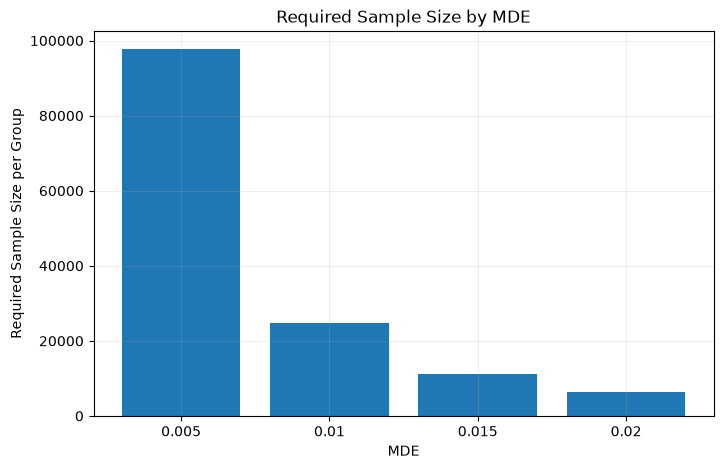

In [7]:
# 여기에 코드를 작성하세요.
mde_list = [0.005, 0.01, 0.015, 0.02]
daily_traffic = 6000
daily_per_group = daily_traffic / 2
max_days = 14

results = []
for mde in mde_list:
    target_rate = baseline + mde
    effect_size = proportion_effectsize(baseline, target_rate)

    n_raw = analysis.solve_power(
        effect_size=effect_size,
        alpha=alpha,
        power=target_power,
        ratio=1.0,
        alternative="two-sided"
    )

    n_per_group = math.ceil(n_raw)
    total_required_n = n_per_group * 2
    expected_days = math.ceil(total_required_n / daily_traffic)
    feasible = "가능" if expected_days <= max_days else "불가능"

    results.append([
        mde,
        effect_size,
        n_per_group,
        total_required_n,
        expected_days,
        feasible
    ])

result_df = pd.DataFrame(
    results,
    columns=[
        "MDE",
        "효과크기",
        "그룹당 필요 표본",
        "전체 필요 표본",
        "예상 실험 일수",
        "14일 내 실행 가능 여부"
    ]
)

print(result_df)

plt.figure(figsize=(8, 5))
plt.bar(
    result_df["MDE"].astype(str),
    result_df["그룹당 필요 표본"]
)

plt.xlabel("MDE")
plt.ylabel("Required Sample Size per Group")
plt.title("Required Sample Size by MDE")
plt.grid(alpha=0.2)
plt.show()

---

## 과제. 운영 제약을 반영한 Cookie Cats 표본 설계

다음 운영 조건에서 MDE 후보 `1.0%p`와 `1.5%p`를 비교하고 실행안을 선택하세요.

### 운영 조건

- 기준 7일 유지율: `gate_30` 관측값
- 유의수준: 0.05
- 목표 검정력: 0.80
- 양측검정, 1:1 배정
- 하루 전체 실험 대상 사용자: 5,000명
- 최대 모집 기간: 7일
- 데이터 누락·이탈 대비 여유 표본: 10%
- 비즈니스적으로 의미 있는 최소 변화: 1.5%p
- 최대 모집 기간 7일은 실험 참여자를 모집하는 기간입니다. 모든 참여자의 7일 유지율을 확인하려면 마지막 참여자 모집 후 추가로 7일의 관찰 기간이 필요합니다.

### 수행 요구사항

1. 두 MDE 후보의 기본 그룹당 표본을 계산하세요.
2. 기본 표본을 `0.90`으로 나누어 10% 누락을 고려한 그룹당 모집 목표를 계산하고 올림하세요.
3. 전체 모집 목표와 예상 모집 기간을 계산하세요.
4. 7일 안에 목표 표본 모집이 가능한지 판단하세요.
5. 아래 질문을 포함하여 5~7문장의 최종 결론을 작성하세요.

### 질문

- 어떤 MDE 설계를 선택해야 하나요?
- 선택한 설계가 통계적 조건과 비즈니스 기준을 모두 만족하나요?
- 선택하지 않은 설계는 왜 현재 운영 조건에 맞지 않나요?
- 실제 실행 전에 추가로 확인해야 할 사항은 무엇인가요?

> 과제는 필수 문제와 동일한 수준이며, 제시된 조건을 같은 계산 절차에 적용하면 됩니다.


In [3]:
# 여기에 코드를 작성하세요.
baseline = df.loc[
    df["version"] == "gate_30",
    "retention_7"
].mean()

alpha = 0.05
power = 0.80
daily_users = 5000
max_days = 7
retention_rate = 0.90

mde_candidates = [0.01, 0.015]

analysis = NormalIndPower()

for mde in mde_candidates:
    target = baseline + mde

    # 기본 그룹당 필요 표본
    base_sample = analysis.solve_power(
        effect_size=abs(proportion_effectsize(baseline, target)),
        alpha=alpha,
        power=power,
        ratio=1.0,
        alternative="two-sided"
    )
    base_sample = math.ceil(base_sample)

    adjusted_sample = math.ceil(base_sample / retention_rate)
    total_sample = adjusted_sample * 2
    expected_days = total_sample / daily_users
    feasible = expected_days <= max_days

    print(f"MDE: {mde * 100:.1f}%p")
    print(f"기준 7일 유지율: {baseline:.4f}")
    print(f"기본 그룹당 표본: {base_sample:,}명")
    print(f"10% 누락 고려 그룹당 모집 목표: {adjusted_sample:,}명")
    print(f"전체 모집 목표: {total_sample:,}명")
    print(f"예상 모집 기간: {expected_days:.2f}일")
    print("7일 내 모집 가능 여부:", "가능" if feasible else "불가능")
    print()

MDE: 1.0%p
기준 7일 유지율: 0.1902
기본 그룹당 표본: 24,658명
10% 누락 고려 그룹당 모집 목표: 27,398명
전체 모집 목표: 54,796명
예상 모집 기간: 10.96일
7일 내 모집 가능 여부: 불가능

MDE: 1.5%p
기준 7일 유지율: 0.1902
기본 그룹당 표본: 11,063명
10% 누락 고려 그룹당 모집 목표: 12,293명
전체 모집 목표: 24,586명
예상 모집 기간: 4.92일
7일 내 모집 가능 여부: 가능



> 5번 최종 결론
- MDE 1.5%p 설계는 10% 누락을 고려할 때 그룹당 12,293명, 전체 24,586명이 필요하며 예상 모집 기간은 약 4.92일이므로 MDE 1.5%p 설계를 선택한다.
- 이 설계는 유의수준 0.05, 목표 검정력 0.80의 통계적 조건을 충족하면서 비즈니스적으로 의미 있는 최소 변화인 1.5%p 기준도 만족한다.
- 또한 최대 모집 기간인 7일 이내에 필요한 표본을 확보할 수 있어 현재 운영 조건에서도 실행 가능하다.
- 반면 MDE 1.0%p 설계는 전체 54,796명이 필요하고 예상 모집 기간이 약 10.96일이므로 최대 모집 기간 7일을 초과하여 현재 운영 조건에 적합하지 않다.
- 실제 실행 전에는 하루 5,000명의 실험 대상 사용자가 안정적으로 유입되는지와 10%의 누락·이탈 여유가 충분한지 추가로 확인해야 한다.
- 또한 7일 유지율은 즉시 확인할 수 없으므로 약 4.92일의 모집이 끝난 뒤 마지막 참여자의 결과를 확인하기 위한 추가 7일의 관찰 기간을 운영 일정에 반영해야 한다.

---

## 실습 마무리

- 어떤 문제가 있었는가?
> 표본을 감으로 정하면 효과 크기를 제대로 알기 어렵고 필요 이상으로 긴 시범 운ㅇ녕을 운영할 수 있다.
> MDE를 적게 설정해도 실제 트래픽을 고려하여 표본을 모을 수 없다면 실행 가능한 설계는 될 수 없다.

- 어떻게 개선했는가?
> 기준 유지율, MDE, 유의수준, 검정력을 사용해 그룹당 표본을 계산하고 실제 트래픽과 모집 기간을 반영했다.

- 무엇을 근거로 개선되었다고 판단했는가?
> MDE 0.5 ~ 2.0까지 표본과 기간을 수치로 비교하여 확인했다.

표본 크기를 감으로 정했을 때의 문제와, 기준선·MDE·검정력·트래픽·운영 기간을 연결하면서 설계가 어떻게 개선되었는지 정리하세요.
